## 1. Imports and Device

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np


## 2. Device Configuration and Seed Initialization

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)


## 3. Load CIFAR-10 Dataset

In [15]:
#Basic Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

#Download Dataset
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

#Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


## 4. CNN Starter Code

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class InitialCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)

        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):

        x = torch.sigmoid(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv4(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)

        x = torch.sigmoid(self.fc1(x))
        x = self.fc2(x)

        return x


## 6. Initialize Network

In [17]:
model = InitialCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


## 7. Training Function

In [18]:
def train(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    gradient_norms = {}

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        # Save gradient norms
        for name, param in model.named_parameters():

            if param.grad is not None:

                grad_norm = param.grad.norm().item()

                if name not in gradient_norms:
                    gradient_norms[name] = []

                gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy, gradient_norms


## 8. Testing Function

In [19]:
def test(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy


## 9. Main Training Loop

In [20]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm

num_epochs = 15

train_losses, test_losses, train_accs, test_accs = [], [], [], []
epoch_gradient_norms = {}

print("Starting Training Process...\n")

# --- חלק 1: לולאת האימון (עם סרגל התקדמות גרפי) ---
pbar = tqdm(range(num_epochs), desc="Training Model", unit="epoch")

for epoch in pbar:
    
    train_loss, train_acc, batch_grad_norms = train(model, train_loader)
    test_loss, test_acc = test(model, test_loader)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    for name, norms in batch_grad_norms.items():
        if name not in epoch_gradient_norms:
            epoch_gradient_norms[name] = []
        epoch_gradient_norms[name].append(np.mean(norms))

    pbar.set_postfix({
        'Train Acc': f"{train_acc:.2f}%", 
        'Test Acc': f"{test_acc:.2f}%"
    })

print("-" * 40)
print("Training Complete. Starting Deep Evaluation on Test Set...\n")

# --- חלק 2: ריצת מבחן סופית לאיסוף נתונים לאנליזות ---
model.eval()
all_labels, all_preds, all_probs, all_logits = [], [], [], []
wrong_images, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_logits.extend(outputs.cpu().numpy())
        
        # איסוף דוגמאות של תמונות שגויות (מוגבל ל-100 כדי לשמור על גודל קובץ סביר)
        wrong_idx = (preds != labels).nonzero(as_tuple=True)[0]
        for idx in wrong_idx:
            if len(wrong_images) < 100:
                wrong_images.append(images[idx].cpu().numpy())
                wrong_true.append(labels[idx].item())
                wrong_pred.append(preds[idx].item())

# --- חלק 3: אריזה ושמירה לקבצים ---
output_dir = r"C:\neural networks\part 1" # תוכל לשנות את התיקייה במידת הצורך
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# הגדרת שמות הקבצים
npz_path = os.path.join(output_dir, "original_cnn_data.npz")
pth_path = os.path.join(output_dir, "original_cnn_weights.pth")

# 1. שמירת משקולות המודל
torch.save(model.state_dict(), pth_path)

# 2. אריזת כל הנתונים למילון ושמירתם ב-NPZ מכווץ
save_dict = {
    'train_losses': np.array(train_losses),
    'test_losses': np.array(test_losses),
    'train_accs': np.array(train_accs),
    'test_accs': np.array(test_accs),
    'all_labels': np.array(all_labels),
    'all_preds': np.array(all_preds),
    'all_probs': np.array(all_probs),
    'all_logits': np.array(all_logits),
    'wrong_images': np.array(wrong_images),
    'wrong_true': np.array(wrong_true),
    'wrong_pred': np.array(wrong_pred)
}

# הוספת הגרדיאנטים עם קידומת 'grad_'
for k, v in epoch_gradient_norms.items():
    save_dict[f'grad_{k}'] = np.array(v)

np.savez_compressed(npz_path, **save_dict)

print(f"Success! Model weights saved to: {pth_path}")
print(f"Success! All analytics data packed and saved to: {npz_path}")

Starting Training Process...



Training Model:   0%|          | 0/15 [00:00<?, ?epoch/s]

----------------------------------------
Training Complete. Starting Deep Evaluation on Test Set...

Success! Model weights saved to: C:\neural networks\part 1\original_cnn_weights.pth
Success! All analytics data packed and saved to: C:\neural networks\part 1\original_cnn_data.npz


# Part 1 answers

## All epochs gradient

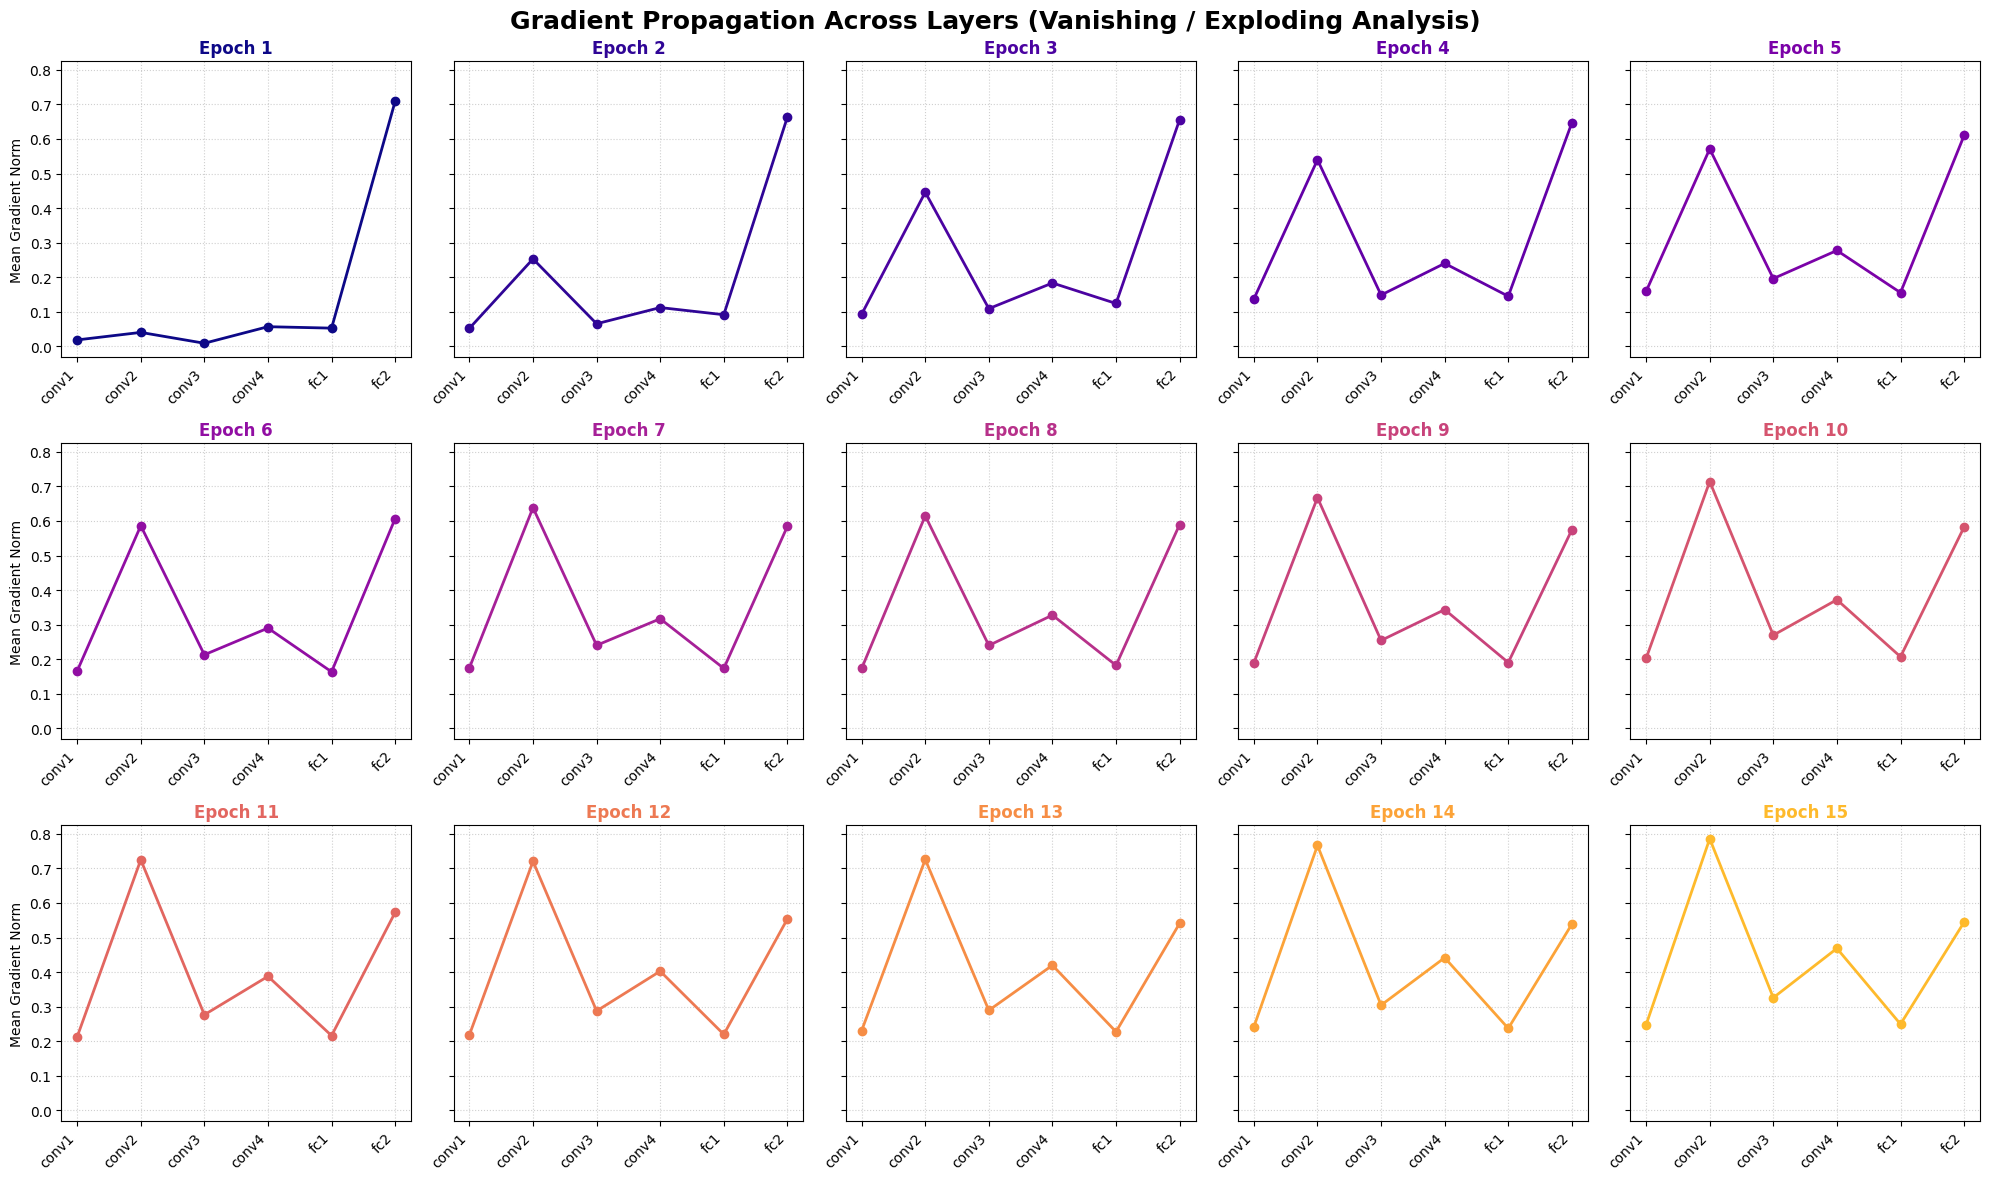

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

output_dir = r"C:\neural networks\part 1"
npz_path = os.path.join(output_dir, "original_cnn_data.npz")
data = np.load(npz_path)

epoch_gradient_norms = {}
for key in data.files:
    if key.startswith('grad_'):
        original_name = key.replace('grad_', '')
        epoch_gradient_norms[original_name] = data[key]

weight_keys = [k for k in epoch_gradient_norms.keys() if 'weight' in k]
layer_labels = [k.replace('.weight', '') for k in weight_keys]
num_epochs = len(epoch_gradient_norms[weight_keys[0]])

fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharey=True)
axes = axes.flat  

colors = cm.plasma(np.linspace(0, 0.85, num_epochs))

for epoch_idx in range(num_epochs):
    ax = axes[epoch_idx]
    
    epoch_norms = [epoch_gradient_norms[name][epoch_idx] for name in weight_keys]
    
    ax.plot(layer_labels, epoch_norms, marker='o', linewidth=2, 
            color=colors[epoch_idx], label=f'Epoch {epoch_idx + 1}')
    
    ax.set_title(f'Epoch {epoch_idx + 1}', fontsize=12, fontweight='bold', color=colors[epoch_idx])
    ax.grid(True, linestyle=':', alpha=0.6)
    
    ax.set_xticks(range(len(layer_labels)))
    ax.set_xticklabels(layer_labels, rotation=45, ha='right')
    
    if epoch_idx % 5 == 0:
        ax.set_ylabel('Mean Gradient Norm')

plt.suptitle('Gradient Propagation Across Layers (Vanishing / Exploding Analysis)', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

## number of parameters

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class InitialCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)

        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = torch.sigmoid(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = torch.sigmoid(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.sigmoid(self.conv3(x))
        x = F.max_pool2d(x, 2)
        x = torch.sigmoid(self.conv4(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc1(x))
        x = self.fc2(x)
        return x

def print_model_parameters(model):
    total_params = 0
    
    print(f"{'Layer / Parameter':<20} | {'Grid Shape':<20} | {'Parameter Count':<15}")
    print("-" * 60)
    
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            
            shape_str = str(list(param.size()))
            print(f"{name:<20} | {shape_str:<20} | {num_params:,}")
            
    print("-" * 60)
    print(f"TOTAL PARAMETERS: {total_params:,}\n")

cnn_model = InitialCNN()
print_model_parameters(cnn_model)

Layer / Parameter    | Grid Shape           | Parameter Count
------------------------------------------------------------
conv1.weight         | [32, 3, 3, 3]        | 864
conv1.bias           | [32]                 | 32
conv2.weight         | [64, 32, 3, 3]       | 18,432
conv2.bias           | [64]                 | 64
conv3.weight         | [128, 64, 3, 3]      | 73,728
conv3.bias           | [128]                | 128
conv4.weight         | [256, 128, 3, 3]     | 294,912
conv4.bias           | [256]                | 256
fc1.weight           | [256, 1024]          | 262,144
fc1.bias             | [256]                | 256
fc2.weight           | [10, 256]            | 2,560
fc2.bias             | [10]                 | 10
------------------------------------------------------------
TOTAL PARAMETERS: 653,386



## memory required

In [ ]:
import torch

def calculate_cnn_memory(model):
    total_params = sum(p.numel() for p in model.parameters())
    
    param_bytes = total_params * 4

    param_mb = param_bytes / (1024 ** 2)
    
    print("-" * 50)
    print("🧠 CNN MEMORY REPORT")
    print("-" * 50)
    print(f"Total Parameters: {total_params:,}")
    print(f"Base Memory (Weights only): {param_mb:.4f} MB")
    
    grad_mb = param_mb
    optimizer_mb = param_mb
    
    total_train_mb = param_mb + grad_mb + optimizer_mb
    
    print(f"\nEstimated Training Memory (Params + Grads + Optimizer): {total_train_mb:.4f} MB")
    print("-" * 50)
    print("*Note: This does not include the memory required for holding the Batch of Images and Intermediate Activations.")

calculate_cnn_memory(cnn_model)

--------------------------------------------------
🧠 CNN MEMORY REPORT
--------------------------------------------------
Total Parameters: 653,386
Base Memory (Weights only): 2.4925 MB

Estimated Training Memory (Params + Grads + Optimizer): 7.4774 MB
--------------------------------------------------
*Note: This does not include the memory required for holding the Batch of Images and Intermediate Activations.


## visualize the filters interpertability

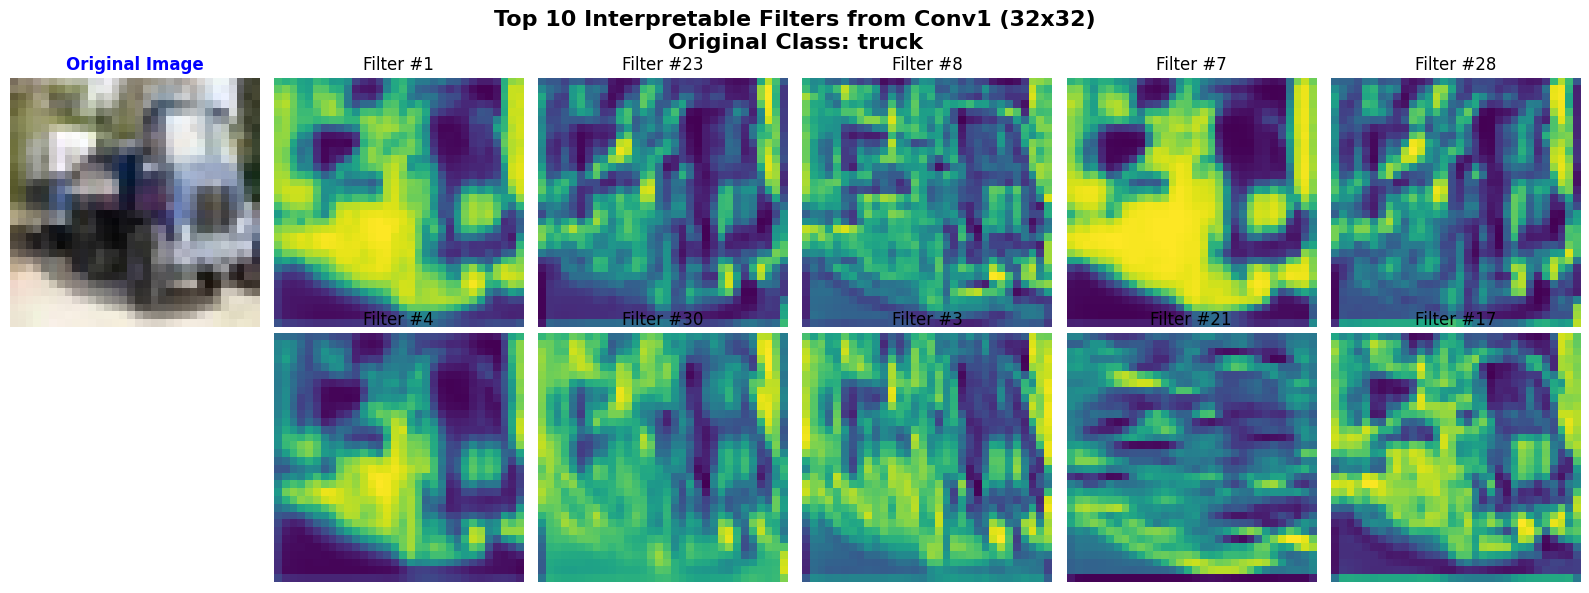

In [ ]:
import matplotlib.pyplot as plt
import torch
import random

model.eval()

dataiter = iter(test_loader)
images, labels = next(dataiter)
idx = random.randint(0, images.size(0) - 1)

img_tensor = images[idx].unsqueeze(0).to(device)
original_img = images[idx].cpu().permute(1, 2, 0).numpy()
original_img = original_img / 2 + 0.5  

with torch.no_grad():

    conv1_out = torch.sigmoid(model.conv1(img_tensor))
    
feature_maps = conv1_out.squeeze(0).cpu().numpy()

chosen_filters = random.sample(range(32), 10)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle(f"Top 10 Interpretable Filters from Conv1 (32x32)\nOriginal Class: {test_dataset.classes[labels[idx]]}", fontsize=16, fontweight='bold')

axes[0, 0].imshow(original_img)
axes[0, 0].set_title("Original Image", color='blue', fontweight='bold')
axes[0, 0].axis('off')
axes[1, 0].axis('off') 


filter_axes = [axes[0, 1], axes[0, 2], axes[0, 3], axes[0, 4], axes[0, 5],
               axes[1, 1], axes[1, 2], axes[1, 3], axes[1, 4], axes[1, 5]]

for i, ax in enumerate(filter_axes):
    f_idx = chosen_filters[i]
    
    ax.imshow(feature_maps[f_idx], cmap='viridis')
    ax.set_title(f"Filter #{f_idx}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Evaluation methods

## loss, accuracy

Plot saved successfully to: C:\neural networks\part 1\loss_accuracy_plot.png


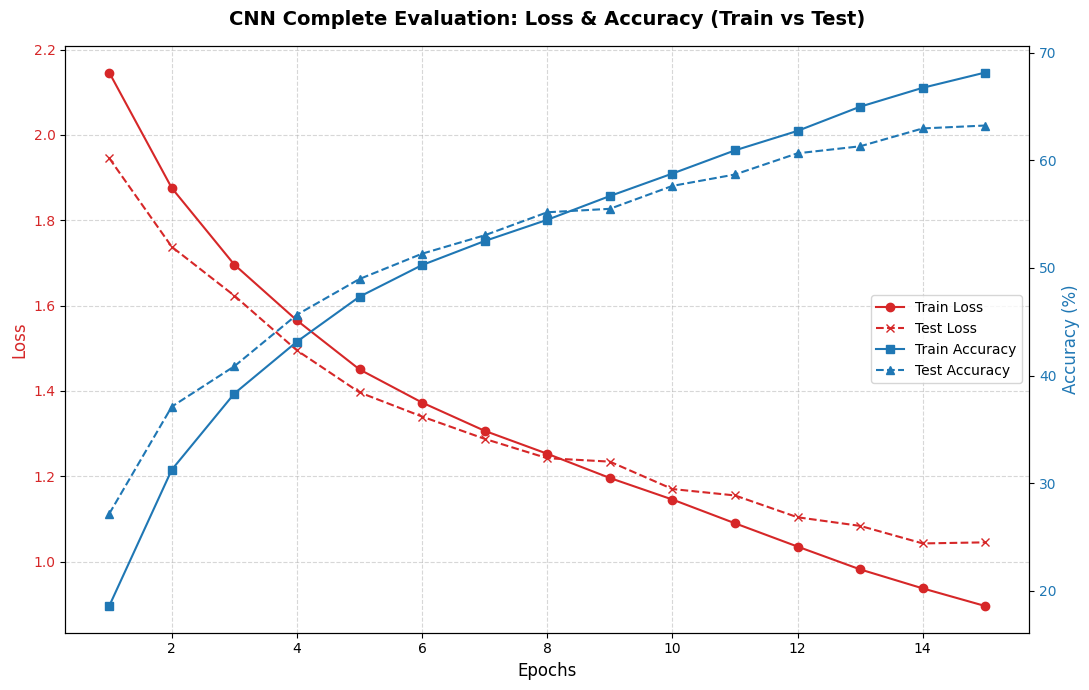

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt


output_dir = r"C:\neural networks\part 1"
npz_path = os.path.join(output_dir, "original_cnn_data.npz")

data = np.load(npz_path)
train_losses = data['train_losses']
test_losses = data['test_losses']
train_accs = data['train_accs']
test_accs = data['test_accs']
num_epochs = len(train_losses)


fig, ax1 = plt.subplots(figsize=(11, 7))


color_loss = 'tab:red'
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', color=color_loss, fontsize=12)


line1 = ax1.plot(range(1, num_epochs + 1), train_losses, color=color_loss, 
                 linestyle='-', marker='o', label='Train Loss')
line2 = ax1.plot(range(1, num_epochs + 1), test_losses, color=color_loss, 
                 linestyle='--', marker='x', label='Test Loss')
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.grid(True, linestyle='--', alpha=0.5)


ax2 = ax1.twinx()  
color_acc = 'tab:blue'
ax2.set_ylabel('Accuracy (%)', color=color_acc, fontsize=12)


line3 = ax2.plot(range(1, num_epochs + 1), train_accs, color=color_acc, 
                 linestyle='-', marker='s', label='Train Accuracy')
line4 = ax2.plot(range(1, num_epochs + 1), test_accs, color=color_acc, 
                 linestyle='--', marker='^', label='Test Accuracy')
ax2.tick_params(axis='y', labelcolor=color_acc)


lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', fontsize=10)


plt.title('CNN Complete Evaluation: Loss & Accuracy (Train vs Test)', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()


plot_path = os.path.join(output_dir, "loss_accuracy_plot.png")
plt.savefig(plot_path, dpi=300)
print(f"Plot saved successfully to: {plot_path}")


plt.show()

## AUC, f1 score

=== F1 Score: 0.6329 ===
הסבר: מדד המאזן בין פספוסים (False Negatives) לאזעקות שווא (False Positives).

Plot saved successfully to: C:\neural networks\part 1\roc_auc_plot.png



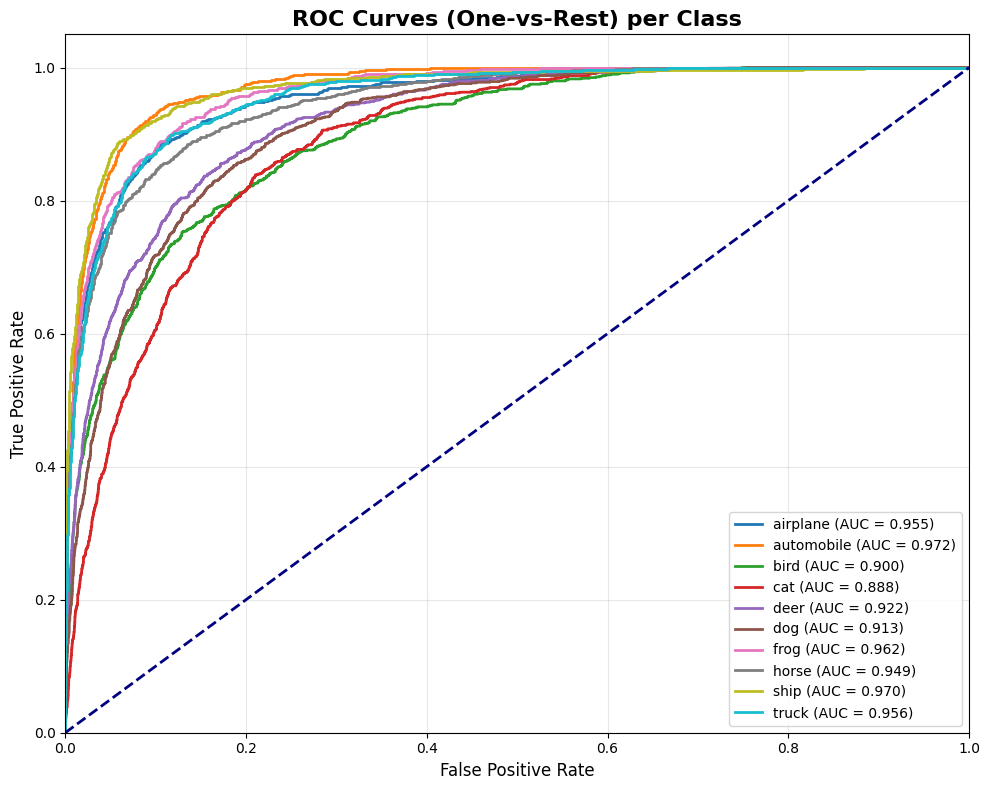

הסבר AUC: הציון נע בין 0.5 (ניחוש לחלוטין) ל-1.0 (הפרדה מושלמת).
מחלקות עם AUC נמוך הן אלו שהמודל הכי מתבלבל בהן לעומת שאר הקטגוריות.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_curve, auc
from sklearn.preprocessing import label_binarize


output_dir = r"C:\neural networks\part 1"
npz_path = os.path.join(output_dir, "original_cnn_data.npz")

data = np.load(npz_path)
all_labels = data['all_labels']
all_preds = data['all_preds']
all_probs = data['all_probs']


cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                 'dog', 'frog', 'horse', 'ship', 'truck']


f1 = f1_score(all_labels, all_preds, average='macro')
print(f"=== F1 Score: {f1:.4f} ===")
print("הסבר: מדד המאזן בין פספוסים (False Negatives) לאזעקות שווא (False Positives).\n")


y_test_bin = label_binarize(all_labels, classes=range(10))

plt.figure(figsize=(10, 8))
for i in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{cifar_classes[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves (One-vs-Rest) per Class', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()


plot_path = os.path.join(output_dir, "roc_auc_plot.png")
plt.savefig(plot_path, dpi=300)
print(f"Plot saved successfully to: {plot_path}\n")


plt.show()

print("הסבר AUC: הציון נע בין 0.5 (ניחוש לחלוטין) ל-1.0 (הפרדה מושלמת).")
print("מחלקות עם AUC נמוך הן אלו שהמודל הכי מתבלבל בהן לעומת שאר הקטגוריות.")

## confusion matrix

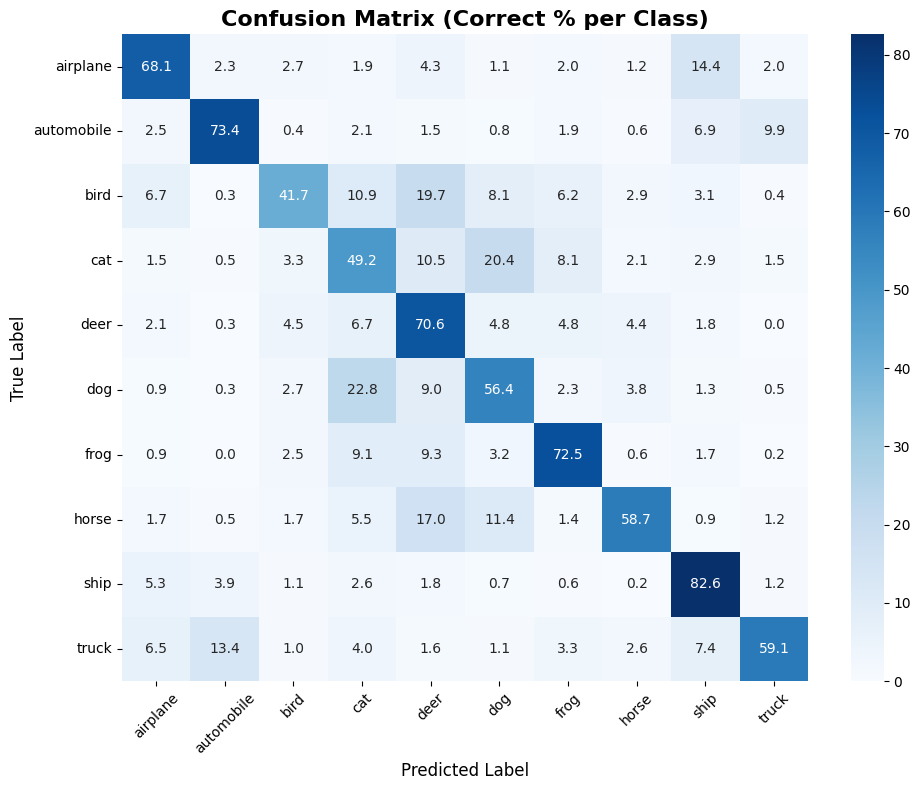

In [31]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
cm_percentages = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(cm_percentages, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=cifar_classes, yticklabels=cifar_classes)
plt.title('Confusion Matrix (Correct % per Class)', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## MisClassification

Plot saved successfully to: C:\neural networks\part 1\misclassified_examples.png



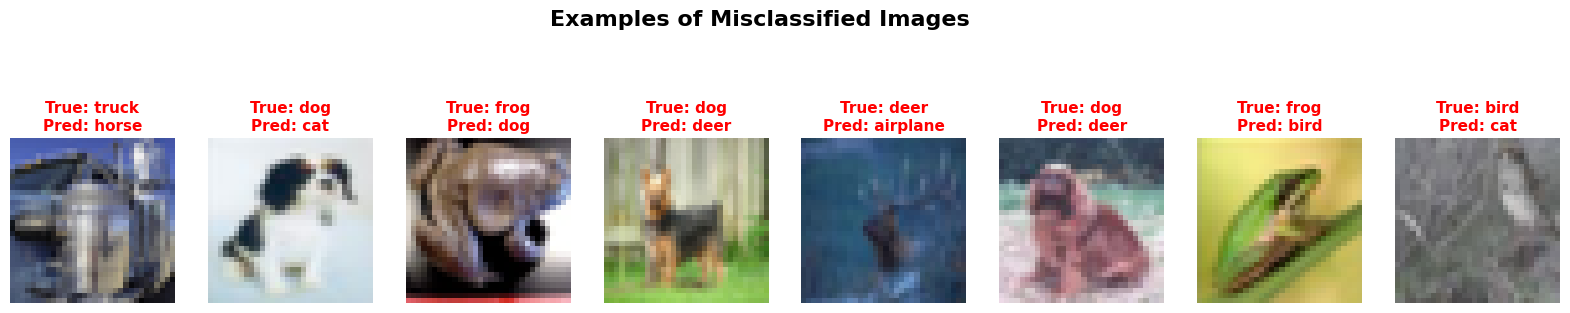

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random


output_dir = r"C:\neural networks\part 1"
npz_path = os.path.join(output_dir, "original_cnn_data.npz")

data = np.load(npz_path)
wrong_images = data['wrong_images']
wrong_true = data['wrong_true']
wrong_pred = data['wrong_pred']

cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                 'dog', 'frog', 'horse', 'ship', 'truck']


def imshow_unnorm(img_array):
    img = img_array / 2 + 0.5    
    img = np.clip(img, 0, 1)      
    return np.transpose(img, (1, 2, 0)) 


num_errors = len(wrong_images)
sample_size = min(8, num_errors)
sample_indices = random.sample(range(num_errors), sample_size)


fig, axes = plt.subplots(1, sample_size, figsize=(20, 3))
if sample_size == 1: axes = [axes]

fig.suptitle('Examples of Misclassified Images', fontsize=16, fontweight='bold', y=1.2)

for ax, idx in zip(axes, sample_indices):
    img_array = wrong_images[idx]
    true_label = cifar_classes[wrong_true[idx]]
    pred_label = cifar_classes[wrong_pred[idx]]
    
    ax.imshow(imshow_unnorm(img_array))
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", 
                 color='red', fontsize=11, fontweight='bold')
    ax.axis('off')


plot_path = os.path.join(output_dir, "misclassified_examples.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to: {plot_path}\n")


plt.show()